# Exercise: Grid World Navigation
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Implement Q-learning algorithm
- Train agent in grid world
- Navigate to goal
- Apply to pathfinding

## Real-World Context

Train agent to navigate mazes, find optimal paths.

**Task**: Build Q-learning agent for grid navigation.

---

## Task 1: Grid World Environment (25 points)

Create grid world:
1. Define grid
2. Set start and goal
3. Define actions and rewards

## Exercise Brief

This exercise checks whether students can implement the full Q-learning loop themselves.

They must connect environment interaction, action selection, value updates, and learning progress into one coherent workflow.

Why this matters: Unit 2 is where RL stops being only conceptual and starts becoming algorithmic.

This exercise verifies that students can translate the lesson into runnable logic.

## Exercise Goal

Build a small grid-world Q-learning setup and explain why the learned values should
improve navigation toward the goal.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np


# Class `GridWorld` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class GridWorld:
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, size.
    def __init__(self, size=5):
        # Save a value in a name so the next lines can read it.
        self.size = size
        # Save a value in a name so the next lines can read it.
        self.start = (0, 0)
        # Save a value in a name so the next lines can read it.
        self.goal = (size - 1, size - 1)
        # Save a value in a name so the next lines can read it.
        self.actions = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        # Save a value in a name so the next lines can read it.
        self.state = self.start

    # Function `reset` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def reset(self):
        # Save a value in a name so the next lines can read it.
        self.state = self.start
        # Send a value back to whoever called this function.
        return self.state_to_index(self.state)

    # Function `state_to_index` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, state.
    def state_to_index(self, state):
        # Send a value back to whoever called this function.
        return state[0] * self.size + state[1]

    # Function `step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, action.
    def step(self, action):
        # Save a value in a name so the next lines can read it.
        dr, dc = self.actions[action]
        # Save a value in a name so the next lines can read it.
        r = min(max(self.state[0] + dr, 0), self.size - 1)
        # Save a value in a name so the next lines can read it.
        c = min(max(self.state[1] + dc, 0), self.size - 1)
        # Save a value in a name so the next lines can read it.
        self.state = (r, c)
        # Unpack the one-step model output from transition(state, action).
        reward = 10 if self.state == self.goal else -1
        # Save a value in a name so the next lines can read it.
        done = self.state == self.goal
        # Send a value back to whoever called this function.
        return self.state_to_index(self.state), reward, done


# Save a value in a name so the next lines can read it.
env = GridWorld(size=5)
# Show text or numbers in the cell output area under the code.
print("Initial state index:", env.reset())


Initial state index: 0


## Task 2: Q-Learning Implementation (35 points)

Implement Q-learning:
1. Initialize Q-table
2. Update Q-values
3. Select actions

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `QLearningAgent` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class QLearningAgent:
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, n_states, n_actions, alpha, gamma, epsilon.
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.95, epsilon=0.1):
        # Save a value in a name so the next lines can read it.
        self.q = np.zeros((n_states, n_actions))
        # Save a value in a name so the next lines can read it.
        self.alpha = alpha
        # Save a value in a name so the next lines can read it.
        self.gamma = gamma
        # Save a value in a name so the next lines can read it.
        self.epsilon = epsilon
        # Save a value in a name so the next lines can read it.
        self.n_actions = n_actions

    # Function `select_action` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, state.
    def select_action(self, state):
        # If the condition is True, run the indented block under this line.
        if np.random.rand() < self.epsilon:
            # Send a value back to whoever called this function.
            return np.random.randint(self.n_actions)
        # Send a value back to whoever called this function.
        return int(np.argmax(self.q[state]))

    # Function `update` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, state, action, reward, next_state.
    def update(self, state, action, reward, next_state):
        # Save a value in a name so the next lines can read it.
        best_next = np.max(self.q[next_state])
        # Save a value in a name so the next lines can read it.
        self.q[state, action] += self.alpha * (
            # Execute: reward + self.gamma * best_next - self.q[state, action]
            reward + self.gamma * best_next - self.q[state, action]
        # Close the parentheses opened earlier (end this function call / grouping).
        )


# Save a value in a name so the next lines can read it.
agent = QLearningAgent(n_states=25, n_actions=4)
# Create or choose a variable used in the Bellman warm-up demo.
state = env.reset()
# Start a loop: repeat the indented block once per item in the sequence.
for _ in range(20):
    # Save a value in a name so the next lines can read it.
    action = agent.select_action(state)
    # Unpack the one-step model output from transition(state, action).
    next_state, reward, done = env.step(action)
    # Execute: agent.update(state, action, reward, next_state)
    agent.update(state, action, reward, next_state)
    # Create or choose a variable used in the Bellman warm-up demo.
    state = next_state
    # If the condition is True, run the indented block under this line.
    if done:
        # Stop the loop completely and continue after the loop block.
        break

# Show text or numbers in the cell output area under the code.
print("Updated Q-table shape:", agent.q.shape)
# Show text or numbers in the cell output area under the code.
print("Task prompt: train longer and explain how epsilon affects learning.")


Updated Q-table shape: (25, 4)
Task prompt: train longer and explain how epsilon affects learning.


## Task 3: Training and Evaluation (40 points)

Train agent and evaluate performance.

**Submission**: Complete notebook with trained agent.

**Grading**: 100 points total

## Reflection

Before submitting, explain:

- why the reward encourages reaching the goal quickly
- how epsilon affects exploration
- why Q-learning updates toward the best next action

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Average reward over last 50 episodes: 1.02
Greedy action at the start state: 1
Reminder: reward is -1 each move and +10 at the goal, so shorter successful paths score higher.


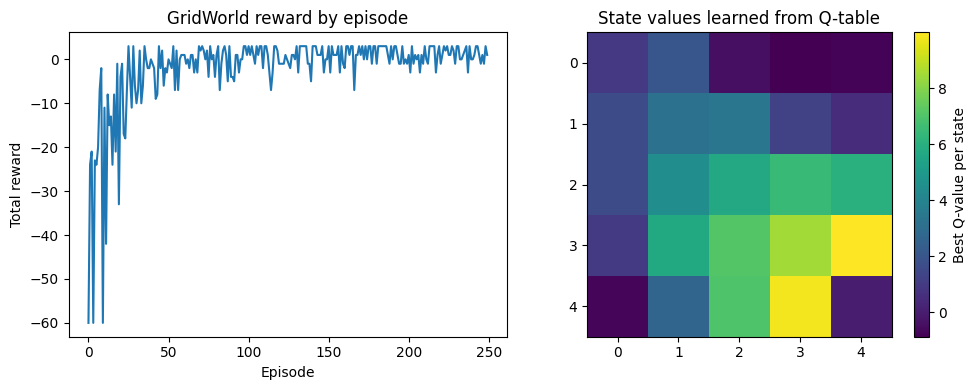

In [3]:
# Worked example: train the same GridWorld-style task that students build in the exercise.
# The goal is to make the feedback, the policy, and the reward shaping feel concrete.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)

# Save a value in a name so the next lines can read it.
env = GridWorld(size=5)
# Save a value in a name so the next lines can read it.
agent = QLearningAgent(n_states=25, n_actions=4, alpha=0.1, gamma=0.95, epsilon=0.2)

# Save a value in a name so the next lines can read it.
episode_rewards = []
# Save a value in a name so the next lines can read it.
episode_steps = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(250):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = env.reset()
    # Save a value in a name so the next lines can read it.
    total_reward = 0

    # Start a loop: repeat the indented block once per item in the sequence.
    for step_idx in range(60):
        # Save a value in a name so the next lines can read it.
        action = agent.select_action(state)
        # Unpack the one-step model output from transition(state, action).
        next_state, reward, done = env.step(action)
        # Execute: agent.update(state, action, reward, next_state)
        agent.update(state, action, reward, next_state)
        # Create or choose a variable used in the Bellman warm-up demo.
        state = next_state
        # Save a value in a name so the next lines can read it.
        total_reward += reward

        # If the condition is True, run the indented block under this line.
        if done:
            # Add one new item to the end of a list (the list grows in place).
            episode_steps.append(step_idx + 1)
            # Stop the loop completely and continue after the loop block.
            break
    # Else: run this block when none of the if/elif tests above matched.
    else:
        # Add one new item to the end of a list (the list grows in place).
        episode_steps.append(60)

    # Add one new item to the end of a list (the list grows in place).
    episode_rewards.append(total_reward)

# Save a value in a name so the next lines can read it.
avg_last_50 = np.mean(episode_rewards[-50:])
# Show text or numbers in the cell output area under the code.
print("Average reward over last 50 episodes:", round(avg_last_50, 2))
# Show text or numbers in the cell output area under the code.
print("Greedy action at the start state:", int(np.argmax(agent.q[env.reset()])))
# Show text or numbers in the cell output area under the code.
print("Reminder: reward is -1 each move and +10 at the goal, so shorter successful paths score higher.")

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 1)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(episode_rewards)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("GridWorld reward by episode")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Episode")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Total reward")

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.imshow(agent.q.max(axis=1).reshape(env.size, env.size), cmap="viridis")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.colorbar(label="Best Q-value per state")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("State values learned from Q-table")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()


## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


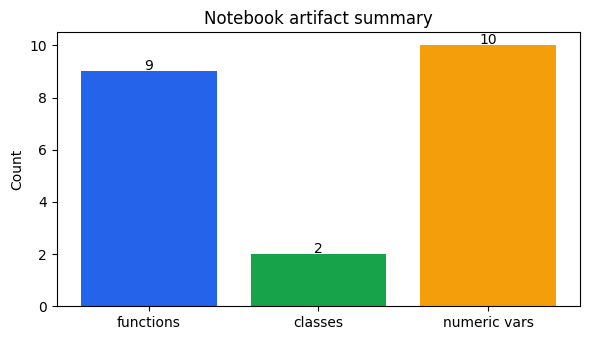

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can apply classical RL updates independently rather than only recognizing them in notes.

**If students remember one idea:** Real understanding appears when a student can explain why an update changed, not just compute it mechanically.

**Quick check before moving on:**
- Can you justify each update in your own words?
- Can you explain how your exploration choice influenced the learned values?

**Bridge to the next step:** After this exercise, students are ready to move from tabular methods toward deep RL representations.
